In [2]:
import numpy as np
import pandas as pd
np.random.seed(18)

In [3]:
X=np.random.uniform(-2,2,(400,3))

y=np.sin(X[:,0])+0.5*(X[:,1]**2)-0.8*X[:,2]
y=y.reshape(-1,1)

X=X.T
y=y.T

In [4]:

def relu(Z):
    return np.maximum(0,Z)

def drelu(Z):
    return (Z>0).astype(float)


def sigmoid(Z):
    return 1/(1+np.exp(-Z))

def dsigmoid(Z):
    s=sigmoid(Z)
    return s*(1-s)


def tanh(Z):
    return np.tanh(Z)

def dtanh(Z):
    return 1-np.tanh(Z)**2


def leaky_relu(Z,alpha=0.01):
    return np.where(Z>0,Z,alpha*Z)

def dleaky_relu(Z,alpha=0.01):
    return np.where(Z>0,1,alpha)


def softplus(Z):
    return np.log(1+np.exp(Z))

def dsoftplus(Z):
    return 1/(1+np.exp(-Z))

In [5]:
def initialize(layer_dims):
    parameters={}
    L=len(layer_dims)-1

    for l in range(1,L+1):
        parameters["W"+str(l)]=np.random.uniform(-0.5,0.5,(layer_dims[l],layer_dims[l-1]))
        parameters["b"+str(l)]=np.zeros((layer_dims[l],1))

    return parameters

In [6]:
def forward(X,parameters,activation):
    caches=[]
    A=X
    L=len(parameters)//2

    for l in range(1,L):
        W=parameters["W"+str(l)]
        b=parameters["b"+str(l)]

        Z=W@A+b
        A=activation(Z)

        caches.append((A,Z))

    W=parameters["W"+str(L)]
    b=parameters["b"+str(L)]

    Z=W@A+b
    A=Z

    caches.append((A,Z))

    return A,caches

In [7]:
def backward(X,y,parameters,caches,activation_derivative):
    grads={}
    L=len(parameters)//2
    m=X.shape[1]

    A_final=caches[-1][0]
    dA=2*(A_final-y)

    for l in reversed(range(1,L+1)):

        A,Z=caches[l-1]

        if l==L:
            dZ=dA
        else:
            dZ=dA*activation_derivative(Z)

        if l==1:
            A_prev=X
        else:
            A_prev=caches[l-2][0]

        grads["dW"+str(l)]=(1/m)*(dZ@A_prev.T)
        grads["db"+str(l)]=(1/m)*np.sum(dZ,axis=1,keepdims=True)

        dA=parameters["W"+str(l)].T@dZ

    return grads

In [8]:
def update(parameters,grads,lr):
    L=len(parameters)//2

    for l in range(1,L+1):
        parameters["W"+str(l)]-=lr*grads["dW"+str(l)]
        parameters["b"+str(l)]-=lr*grads["db"+str(l)]

    return parameters

In [9]:
def train(layer_dims,activation,activation_derivative):

    parameters=initialize(layer_dims)

    lr=0.01
    epochs=1000
    loss_200=None

    for epoch in range(epochs):

        y_hat,caches=forward(X,parameters,activation)
        loss=np.mean((y_hat-y)**2)

        if epoch==200:
            loss_200=loss

        grads=backward(X,y,parameters,caches,activation_derivative)
        parameters=update(parameters,grads,lr)

    grad_norm_L1=np.linalg.norm(grads["dW1"])
    last_hidden=len(layer_dims)-2
    grad_norm_last=np.linalg.norm(grads["dW"+str(last_hidden)])

    return loss,loss_200,grad_norm_L1,grad_norm_last

In [10]:
models={
    "Model A (Shallow-1HiddenLayer)":[3,4,1],
    "Model B (Medium-2HiddenLayers)":[3,6,6,1],
    "Model C (Deep-4HiddenLayers)":[3,8,8,8,8,1],
    "Model D (VeryDeep-8HiddenLayers)":[3,8,8,8,8,8,8,8,8,1]
}

In [11]:
results=[]

for name in [
    "Model A (Shallow-1HiddenLayer)",
    "Model B (Medium-2HiddenLayers)",
    "Model C (Deep-4HiddenLayers)"
]:
    dims=models[name]
    final_loss,loss_200,g1,glast=train(dims,relu,drelu)
    results.append([name,"ReLU",final_loss,loss_200,g1,glast])

name="Model D (VeryDeep-8HiddenLayers)"

final_loss,loss_200,g1,glast=train(models[name],relu,drelu)
results.append([name,"ReLU",final_loss,loss_200,g1,glast])

final_loss,loss_200,g1,glast=train(models[name],sigmoid,dsigmoid)
results.append([name,"Sigmoid",final_loss,loss_200,g1,glast])

In [12]:
df=pd.DataFrame(
    results,
    columns=[
        "Model",
        "Activation",
        "FinalLoss",
        "Loss@200",
        "GradNorm_L1",
        "GradNorm_LastHidden"
    ]
)

print(df)

                              Model Activation  FinalLoss  Loss@200  \
0    Model A (Shallow-1HiddenLayer)       ReLU   0.131369  0.668043   
1    Model B (Medium-2HiddenLayers)       ReLU   0.058519  0.433424   
2      Model C (Deep-4HiddenLayers)       ReLU   0.049361  0.226364   
3  Model D (VeryDeep-8HiddenLayers)       ReLU   0.119236  1.825270   
4  Model D (VeryDeep-8HiddenLayers)    Sigmoid   1.829255  1.829255   

   GradNorm_L1  GradNorm_LastHidden  
0     0.020756             0.020756  
1     0.029155             0.029873  
2     0.032114             0.023107  
3     0.085169             0.129117  
4     0.000007             0.000006  


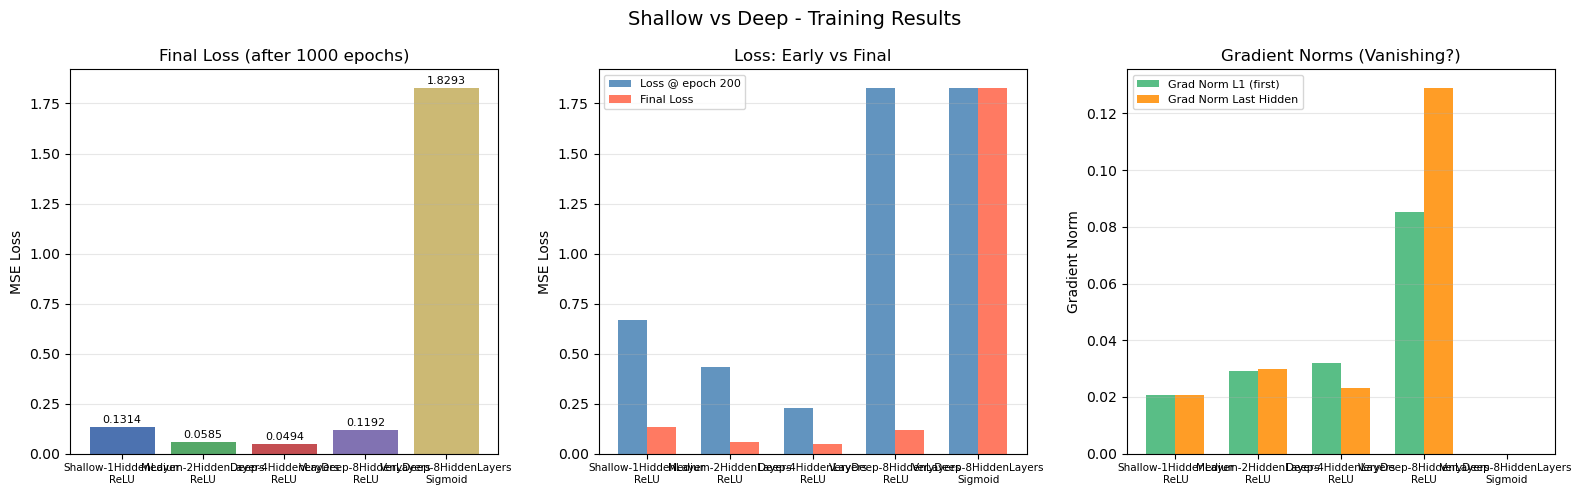

In [13]:
import matplotlib.pyplot as plt

labels = []
for m, a in zip(df['Model'], df['Activation']):
    short = m.split('(')[1].replace(')', '')
    labels.append(short + '\n' + a)

final_losses = df['FinalLoss'].tolist()
loss200 = df['Loss@200'].tolist()
grad_l1 = df['GradNorm_L1'].tolist()
grad_last = df['GradNorm_LastHidden'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Shallow vs Deep - Training Results', fontsize=14)

colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars = axes[0].bar(range(len(labels)), final_losses, color=colors)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=7.5)
axes[0].set_title('Final Loss (after 1000 epochs)')
axes[0].set_ylabel('MSE Loss')
for bar, val in zip(bars, final_losses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.4f}', ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

width = 0.35
x = range(len(labels))
axes[1].bar([i - width/2 for i in x], loss200, width, label='Loss @ epoch 200', color='steelblue', alpha=0.85)
axes[1].bar([i + width/2 for i in x], final_losses, width, label='Final Loss', color='tomato', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, fontsize=7.5)
axes[1].set_title('Loss: Early vs Final')
axes[1].set_ylabel('MSE Loss')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar([i - width/2 for i in x], grad_l1, width, label='Grad Norm L1 (first)', color='mediumseagreen', alpha=0.85)
axes[2].bar([i + width/2 for i in x], grad_last, width, label='Grad Norm Last Hidden', color='darkorange', alpha=0.85)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(labels, fontsize=7.5)
axes[2].set_title('Gradient Norms (Vanishing?)')
axes[2].set_ylabel('Gradient Norm')
axes[2].legend(fontsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
print('Summary')
print('-' * 55)
for i, row in df.iterrows():
    drop = row['Loss@200'] - row['FinalLoss']
    ratio = row['GradNorm_L1'] / (row['GradNorm_LastHidden'] + 1e-10)
    print(f"{row['Model']} | {row['Activation']}")
    print(f"  Loss drop (epoch200 -> final): {drop:.4f}")
    print(f"  GradNorm L1: {row['GradNorm_L1']:.6f}  |  Last Hidden: {row['GradNorm_LastHidden']:.6f}")
    if row['GradNorm_L1'] < 0.001:
        print('  >> Vanishing gradients!')
    print()


Summary
-------------------------------------------------------
Model A (Shallow-1HiddenLayer) | ReLU
  Loss drop (epoch200 -> final): 0.5367
  GradNorm L1: 0.020756  |  Last Hidden: 0.020756

Model B (Medium-2HiddenLayers) | ReLU
  Loss drop (epoch200 -> final): 0.3749
  GradNorm L1: 0.029155  |  Last Hidden: 0.029873

Model C (Deep-4HiddenLayers) | ReLU
  Loss drop (epoch200 -> final): 0.1770
  GradNorm L1: 0.032114  |  Last Hidden: 0.023107

Model D (VeryDeep-8HiddenLayers) | ReLU
  Loss drop (epoch200 -> final): 1.7060
  GradNorm L1: 0.085169  |  Last Hidden: 0.129117

Model D (VeryDeep-8HiddenLayers) | Sigmoid
  Loss drop (epoch200 -> final): 0.0000
  GradNorm L1: 0.000007  |  Last Hidden: 0.000006
  >> Vanishing gradients!

